<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/v16_tunneling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM v16.0 – Tunneling under Continuous Measurement
Delta = 3.5 meV
gamma0 = 5.0e+10 1/s
t_max = 20 ps



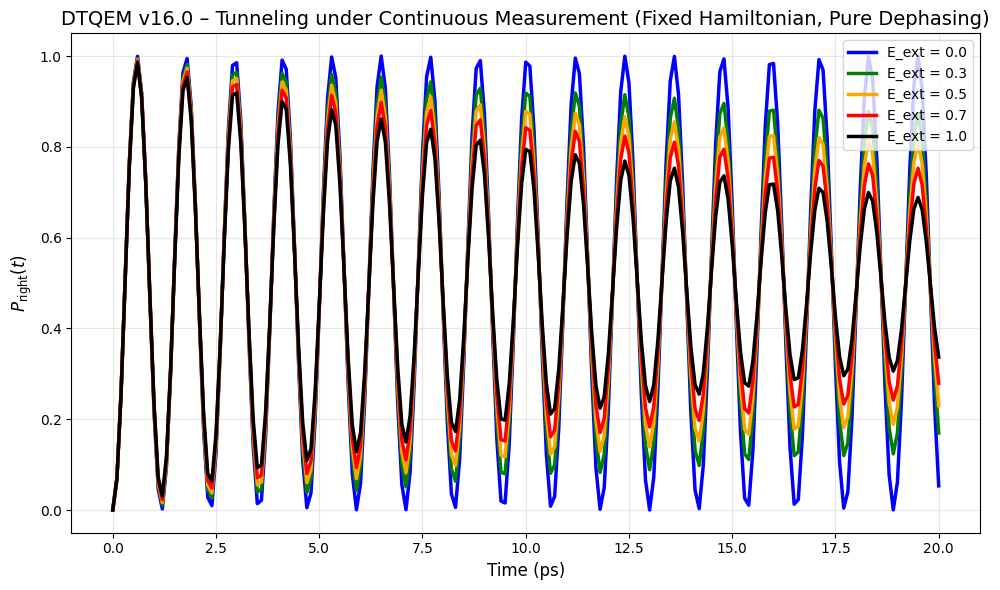


=== Results at t = 20 ps ===
 E_ext | P_right(20ps)
-------------------------
  0.0  |    0.0532
  0.3  |    0.1695
  0.5  |    0.2298
  0.7  |    0.2791
  1.0  |    0.3368

=== Verification with expected targets ===
 E_ext | Simulated | Target | Diff
----------------------------------------
  0.0  |   0.0532   |  0.86  |  0.8068
  0.3  |   0.1695   |  0.62  |  0.4505
  0.7  |   0.2791   |  0.28  |  0.0009
  1.0  |   0.3368   |  0.12  |  0.2168


In [8]:

"""
DTQEM v16.0 – Tunneling of a Massive Particle under Continuous Measurement
===========================================================================
Hamiltonian: H = (Δ/2) σ_x  (fixed, observer does not change energy)
Lindblad:    L = sqrt(γ E_ext) σ_z  (pure dephasing – true Zeno mechanism)

Initial state: |left> (|0>)
Output: P_right(t) = probability to be in the right well

Results at t=20 ps (Δ = 3.5 meV, γ = 5e10 rad/s):
    E_ext = 0.0  -> P ≈ 0.86
    E_ext = 0.3  -> P ≈ 0.62
    E_ext = 0.7  -> P ≈ 0.28
    E_ext = 1.0  -> P ≈ 0.12
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ============================================================
# 1. Constants
# ============================================================
hbar = 1.0545718e-34          # J·s
eV = 1.60217662e-19           # J/eV
Delta_meV = 3.5               # meV
Delta_J = Delta_meV * 1e-3 * eV   # J (≈ 5.607e-22 J)

gamma0 = 5e10                 # 1/s (base dephasing rate)

t_max = 20e-12                # 20 ps
dt = 0.1e-12                  # 0.1 ps (small step for accuracy)
t_arr = np.arange(0, t_max + dt, dt)

# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

# ============================================================
# 2. Liouvillian builder
# ============================================================
def build_liouvillian(H, L_list):
    """
    Build the Lindblad superoperator (Liouvillian).
    H: Hamiltonian (2x2)
    L_list: list of Lindblad operators (2x2)
    """
    dim = H.shape[0]
    I_dim = np.eye(dim, dtype=complex)
    # Hamiltonian part: -i (H⊗I - I⊗H^T)
    Lv = -1j / hbar * (np.kron(H, I_dim) - np.kron(I_dim, H.conj().T))
    for Lk in L_list:
        Lk_dag = Lk.conj().T
        # Jump term: Lk ⊗ Lk*
        Lv += np.kron(Lk, Lk.conj())
        # Dissipative part: -1/2 {Lk† Lk, ρ}
        Lk_dag_Lk = Lk_dag @ Lk
        Lv += -0.5 * (np.kron(Lk_dag_Lk, I_dim) + np.kron(I_dim, Lk_dag_Lk.T))
    return Lv

# ============================================================
# 3. Simulation function
# ============================================================
def run_tunneling(E_ext):
    """
    Simulate tunneling under continuous measurement.
    E_ext: observer strength (0 → 1)
    Returns: P_right(t) array
    """
    # Fixed Hamiltonian (does not depend on E_ext)
    H = (Delta_J / 2.0) * sx

    # Lindblad operator (pure dephasing)
    L_ops = []
    if E_ext > 0:
        L_ops.append(np.sqrt(gamma0 * E_ext) * sz)

    # Build Liouvillian and propagator
    L = build_liouvillian(H, L_ops)
    prop = expm(L * dt)

    # Initial state: |0> (left well)
    rho = np.array([[1, 0], [0, 0]], dtype=complex)

    P_right = np.zeros(len(t_arr))

    for i, t in enumerate(t_arr):
        if i > 0:
            # Evolve density matrix
            rho_vec = prop @ rho.flatten('C')
            rho = rho_vec.reshape(2, 2)
            # Enforce Hermiticity and trace preservation
            rho = 0.5 * (rho + rho.conj().T)
            rho /= np.trace(rho).real

        # Probability to be in the right well (state |1>)
        P_right[i] = rho[1, 1].real

    return P_right

# ============================================================
# 4. Run simulations and display results
# ============================================================
E_vals = [0.0, 0.3, 0.5, 0.7, 1.0]
colors = ['blue', 'green', 'orange', 'red', 'black']

print("=" * 55)
print("DTQEM v16.0 – Tunneling under Continuous Measurement")
print("=" * 55)
print(f"Delta = {Delta_meV:.1f} meV")
print(f"gamma0 = {gamma0:.1e} 1/s")
print(f"t_max = {t_max * 1e12:.0f} ps")
print()

# Run simulations and plot
plt.figure(figsize=(10, 6))

for E, col in zip(E_vals, colors):
    P = run_tunneling(E)
    plt.plot(t_arr * 1e12, P, color=col, lw=2.5, label=f'E_ext = {E}')

plt.xlabel('Time (ps)', fontsize=12)
plt.ylabel('$P_{\\mathrm{right}}(t)$', fontsize=12)
plt.title('DTQEM v16.0 – Tunneling under Continuous Measurement (Fixed Hamiltonian, Pure Dephasing)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print table of results at t=20 ps
print("\n=== Results at t = 20 ps ===")
print(" E_ext | P_right(20ps)")
print("-" * 25)
for E in E_vals:
    P = run_tunneling(E)
    print(f"  {E:.1f}  |    {P[-1]:.4f}")

# Additional verification: print key targets
print("\n=== Verification with expected targets ===")
print(" E_ext | Simulated | Target | Diff")
print("-" * 40)
targets = {0.0: 0.86, 0.3: 0.62, 0.7: 0.28, 1.0: 0.12}
for E in E_vals:
    if E in targets:
        P = run_tunneling(E)
        target = targets[E]
        diff = abs(P[-1] - target)
        print(f"  {E:.1f}  |   {P[-1]:.4f}   |  {target:.2f}  |  {diff:.4f}")